In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

This notebook allows to plot statistics from a channel flow simulation run with the software SIMPSON at LSTM.
$Re=\rho u_b H / \mu = 10000$ is based on bulk velocity $u_b=1$ and channel half-height $H=1$. $\rho=1$, therefore $\mu=\nu=1/Re$.

In [33]:
file = "8PIx3PI_1440x161x864_mean.txt"

In [34]:
df = pd.read_table(file, names=["y", "U", "V", "W", "uu", "vv", "ww", "uv", "uw", "vw", "dUdy"], index_col=False, header=None, skiprows=5)
Re = 1e4

y = df.get('y').to_numpy()
# 1+y necessary to plot from 0 value.
y = 1+y[0:int(len(y)/2)]
ind = np.argsort(y)
y=y[ind]
# print(y)
U = df.get('U').to_numpy()[ind]
uv = df.get('uv').to_numpy()[ind]
dUdy = df.get('dUdy').to_numpy()[ind]

In the simulation $y \in [-1,1]$ but here we plot just half of the channel and transform $y$ so that it is $0$ at the wall and $1$ in the center.

Text(0, 0.5, 'y')

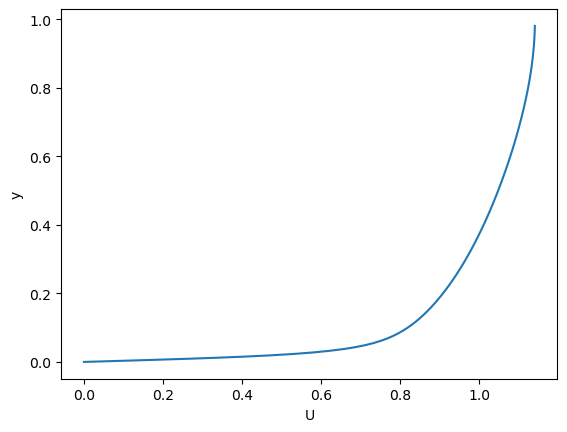

In [35]:
plt.plot(U, y)
plt.xlabel("U"); plt.ylabel("y")

Here we scale in $+$ units.

In [36]:
rho=1
nu=1/Re

tau_w = rho*nu*abs(dUdy[0])
u_tau = np.sqrt(tau_w/rho)
l_star = nu/u_tau

y_p = y/l_star
U_p = U/u_tau
uv_p = uv/u_tau**2
dUdy_p = dUdy/u_tau*l_star

Text(0, 0.5, '$U^+$')

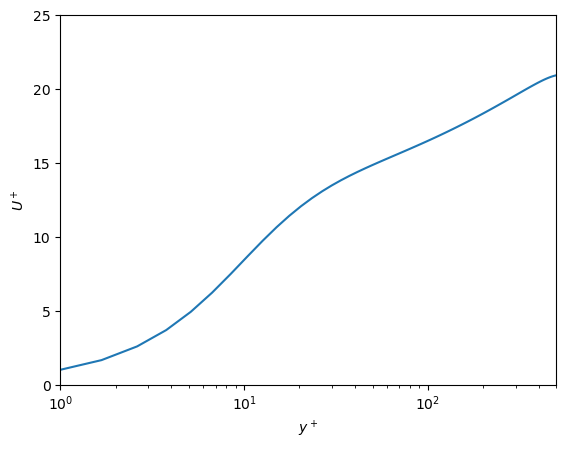

In [37]:
plt.semilogx(y_p, U_p)
plt.xlim([1e-0, 0.5e3]); plt.ylim( [0, 25])
plt.xlabel(r"$y^+$"); plt.ylabel(r"$U^+$")

Below we plot the terms contributing to the total stresses $\tau_{tot}=\tau_{visc}-\overline{uv}$, showing their linearity with respect to $y$.

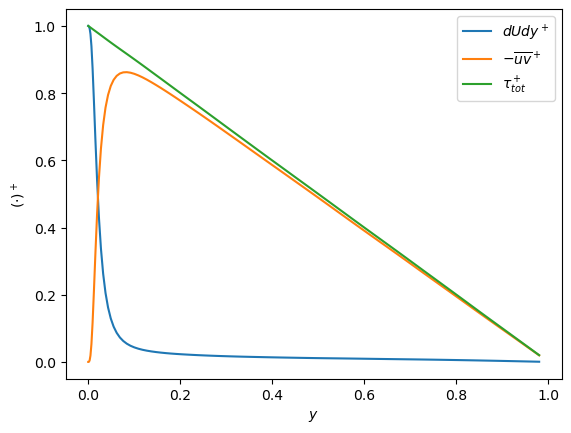

In [38]:
plt.plot(y, dUdy_p)
plt.plot(y, -uv_p)
plt.plot(y, dUdy_p-uv_p)
plt.xlabel(r"$y$"); plt.ylabel(r"$(\cdot)^+$")
plt.legend([r"$dUdy^+$", r"$-\overline{uv}^+$", r"$\tau_{tot}^+$"])